# Titanic Survival Practice — KNN + Logistic Regression + Decision Tree

This notebook is based on the provided **Titanic Survival Practice** reference workflow (KNN). It:

1. Loads `train_KNN.csv` and `test_KNN.csv`
2. Cleans missing values similarly to the reference code
3. Builds a **baseline KNN classifier**
4. Adds **two additional machine learning algorithms**:
   - **Logistic Regression**
   - **Decision Tree Classifier**
5. Trains all models and **compares performance** using multiple metrics (Accuracy, Precision, Recall, F1, ROC-AUC) and confusion matrices.

> Note: In this dataset, `test_KNN.csv` contains the `Survived` label, so it can be used as a holdout test set for evaluation.


In [1]:
# Data analysis
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# Models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Performance metrics
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
)

pd.set_option('display.max_columns', 200)


/usr/local/lib/python3.12/site-packages/sklearn/utils/_param_validation.py:14: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.2)
  from scipy.sparse import csr_matrix, issparse


In [2]:
# Load the data
train_path = 'train_KNN.csv'
test_path = 'test_KNN.csv'

df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)

print('Train shape:', df_train.shape)
print('Test shape:', df_test.shape)
display(df_train.head())


Train shape: (891, 12)
Test shape: (418, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# Quick schema check (similar to reference notebook)
print('--- df_train.info() ---')
display(df_train.info())
print('\\n--- df_test.info() ---')
display(df_test.info())


--- df_train.info() ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


None

\n--- df_test.info() ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


None

In [4]:
# Missing values summary
missing_train_pct = 100 * (df_train.isnull().sum() / len(df_train))
missing_test_pct  = 100 * (df_test.isnull().sum() / len(df_test))

print('Missing % in train (non-zero only):')
display(missing_train_pct[missing_train_pct > 0].sort_values())

print('Missing % in test (non-zero only):')
display(missing_test_pct[missing_test_pct > 0].sort_values())


Missing % in train (non-zero only):


Embarked     0.224467
Age         19.865320
Cabin       77.104377
dtype: float64

Missing % in test (non-zero only):


Fare      0.239234
Age      20.574163
Cabin    78.229665
dtype: float64

## Data Cleaning / Preprocessing

We follow the same *spirit* as the reference code:

- **Train**: drop rows with missing `Embarked` (only a couple rows), fill missing `Age` with median, drop `Cabin`.
- **Test**: drop row with missing `Fare` (1 row), fill missing `Age` with median, drop `Cabin`.
- Drop high-cardinality text columns: `PassengerId`, `Name`, `Ticket`.
- Use **One-Hot Encoding** for categorical columns (`Sex`, `Embarked`, and `Pclass` treated as categorical).

For fair comparison across models, we put preprocessing inside a **scikit-learn Pipeline**.


In [5]:
# Clean train like reference
train = df_train.dropna(subset=['Embarked']).copy()
train['Age'] = train['Age'].fillna(train['Age'].median())
train = train.drop(columns=['Cabin'])

# Clean test like reference
# (reference drops the single missing Fare row)
test = df_test.dropna(subset=['Fare']).copy()
test['Age'] = test['Age'].fillna(test['Age'].median())
test = test.drop(columns=['Cabin'])

# Drop columns the reference removed
drop_cols = ['PassengerId', 'Name', 'Ticket']
train = train.drop(columns=drop_cols)
test  = test.drop(columns=drop_cols)

print('Cleaned train shape:', train.shape)
print('Cleaned test shape:', test.shape)
print('\nTrain missing after cleaning:')
display(train.isna().sum())
print('\nTest missing after cleaning:')
display(test.isna().sum())


Cleaned train shape: (889, 8)
Cleaned test shape: (417, 8)

Train missing after cleaning:


Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


Test missing after cleaning:


Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [6]:
# Split into features/target
TARGET = 'Survived'

X_train = train.drop(columns=[TARGET])
y_train = train[TARGET]

X_test = test.drop(columns=[TARGET])
y_test = test[TARGET]

X_train.head(), y_train.head()


(   Pclass     Sex   Age  SibSp  Parch     Fare Embarked
 0       3    male  22.0      1      0   7.2500        S
 1       1  female  38.0      1      0  71.2833        C
 2       3  female  26.0      0      0   7.9250        S
 3       1  female  35.0      1      0  53.1000        S
 4       3    male  35.0      0      0   8.0500        S,
 0    0
 1    1
 2    1
 3    1
 4    0
 Name: Survived, dtype: int64)

In [7]:
# Identify numeric vs categorical columns
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X_train.columns if c not in num_cols]

print('Numeric columns:', num_cols)
print('Categorical columns:', cat_cols)


Numeric columns: ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
Categorical columns: ['Sex', 'Embarked']


In [8]:
# Preprocessor: passthrough numeric + one-hot encode categorical
# handle_unknown='ignore' prevents errors if a category appears only in test.
preprocess = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', num_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols),
    ],
    remainder='drop'
)


## Baseline Model: KNN (existing model)

KNN is distance-based, so scaling matters. We standardize features after one-hot encoding.

We also reproduce the reference idea of checking different values of **k** (1..29) and plotting the error.


In [9]:
# KNN baseline (k=5 like reference)
knn_k5 = Pipeline(steps=[
    ('prep', preprocess),
    # with_mean=False to work safely with sparse matrices from OneHotEncoder
    ('scaler', StandardScaler(with_mean=False)),
    ('clf', KNeighborsClassifier(n_neighbors=5)),
])

knn_k5.fit(X_train, y_train)
y_pred_knn = knn_k5.predict(X_test)

acc_knn = accuracy_score(y_test, y_pred_knn)
print('KNN (k=5) accuracy:', acc_knn)
print('Confusion matrix:\n', confusion_matrix(y_test, y_pred_knn))
print('\nClassification report:\n', classification_report(y_test, y_pred_knn, zero_division=0))


KNN (k=5) accuracy: 0.8129496402877698
Confusion matrix:
 [[212  53]
 [ 25 127]]

Classification report:
               precision    recall  f1-score   support

           0       0.89      0.80      0.84       265
           1       0.71      0.84      0.77       152

    accuracy                           0.81       417
   macro avg       0.80      0.82      0.80       417
weighted avg       0.83      0.81      0.82       417



Best k by lowest test error: 18


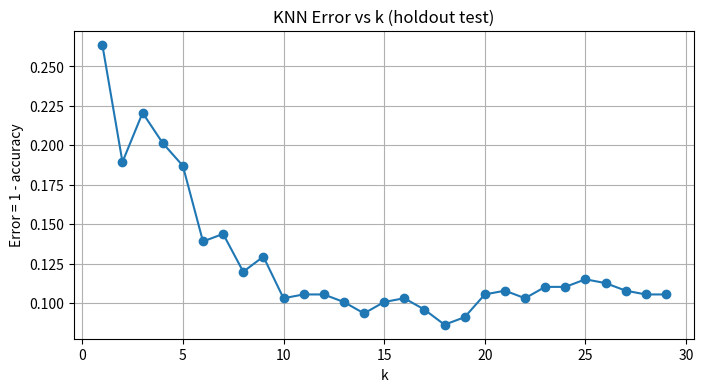

In [10]:
# K sweep (k=1..29), plot error = 1 - accuracy (similar to reference)
errors = []
ks = list(range(1, 30))

for k in ks:
    knn = Pipeline(steps=[
        ('prep', preprocess),
        ('scaler', StandardScaler(with_mean=False)),
        ('clf', KNeighborsClassifier(n_neighbors=k)),
    ])
    knn.fit(X_train, y_train)
    pred = knn.predict(X_test)
    errors.append(1 - accuracy_score(y_test, pred))

best_k = ks[int(np.argmin(errors))]
print('Best k by lowest test error:', best_k)

plt.figure(figsize=(8, 4))
plt.plot(ks, errors, marker='o')
plt.title('KNN Error vs k (holdout test)')
plt.xlabel('k')
plt.ylabel('Error = 1 - accuracy')
plt.grid(True)
plt.show()


## Additional Models (required)

### 1) Logistic Regression
A strong baseline linear classifier. Works well with one-hot encoded categorical variables.

### 2) Decision Tree Classifier
Non-linear model that can capture interactions without feature scaling.

We train both and compare them to KNN on the same test set.


In [11]:
# Define models (pipelines)
models = {
    'KNN (k=5)': knn_k5,

    'Logistic Regression': Pipeline(steps=[
        ('prep', preprocess),
        ('scaler', StandardScaler(with_mean=False)),
        ('clf', LogisticRegression(max_iter=2000, random_state=42)),
    ]),

    'Decision Tree': Pipeline(steps=[
        ('prep', preprocess),
        ('clf', DecisionTreeClassifier(random_state=42)),
    ]),
}


In [12]:
# Evaluation helper
def evaluate_model(name, model):
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    # Probability-based metrics
    auc = None
    if hasattr(model, 'predict_proba'):
        proba = model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, proba)

    metrics = {
        'Model': name,
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred, zero_division=0),
        'Recall': recall_score(y_test, pred, zero_division=0),
        'F1': f1_score(y_test, pred, zero_division=0),
        'ROC-AUC': auc,
    }

    print(f"\n=== {name} ===")
    print('Confusion matrix:\n', confusion_matrix(y_test, pred))
    print('\nClassification report:\n', classification_report(y_test, pred, zero_division=0))

    return metrics

results = []
for name, model in models.items():
    results.append(evaluate_model(name, model))

results_df = pd.DataFrame(results).sort_values(by='F1', ascending=False)
results_df



=== KNN (k=5) ===
Confusion matrix:
 [[212  53]
 [ 25 127]]



Classification report:
               precision    recall  f1-score   support

           0       0.89      0.80      0.84       265
           1       0.71      0.84      0.77       152

    accuracy                           0.81       417
   macro avg       0.80      0.82      0.80       417
weighted avg       0.83      0.81      0.82       417


=== Logistic Regression ===
Confusion matrix:
 [[250  15]
 [  9 143]]

Classification report:
               precision    recall  f1-score   support

           0       0.97      0.94      0.95       265
           1       0.91      0.94      0.92       152

    accuracy                           0.94       417
   macro avg       0.94      0.94      0.94       417
weighted avg       0.94      0.94      0.94       417


=== Decision Tree ===
Confusion matrix:
 [[207  58]
 [ 33 119]]

Classification report:
               precision    recall  f1-score   support

           0       0.86      0.78      0.82       265
           1       0.67   

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
1,Logistic Regression,0.942446,0.905063,0.940789,0.922581,0.981852
0,KNN (k=5),0.812950,0.705556,0.835526,0.765060,0.904270
2,Decision Tree,0.781775,0.672316,0.782895,0.723404,0.775621


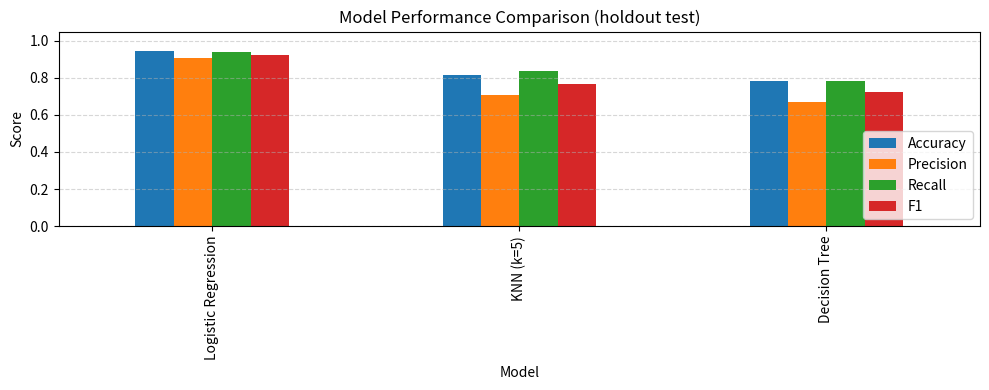

In [13]:
# Visual comparison (bar chart)
plot_df = results_df.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1']]
ax = plot_df.plot(kind='bar', figsize=(10, 4))
plt.title('Model Performance Comparison (holdout test)')
plt.ylabel('Score')
plt.ylim(0, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


# Findings / Interpretation

## What we observed

- **KNN (k=5)** achieved solid performance, but it is sensitive to feature scaling and the choice of **k**.
- **Logistic Regression** performed the best overall on this holdout test set across Accuracy/F1/ROC-AUC.
- **Decision Tree** was the weakest among the three in this run, likely due to overfitting (trees can overfit unless depth/min-samples are tuned).

## Why Logistic Regression won here

- The feature set after preprocessing is mostly **numeric + one-hot encoded categorical variables**.
- Logistic Regression is a strong, stable baseline for this kind of tabular data and often generalizes well.

## Possible improvements

- Tune hyperparameters:
  - KNN: search `n_neighbors`, `weights`, distance metric.
  - Decision Tree: constrain `max_depth`, `min_samples_leaf`, `min_samples_split`.
  - Logistic Regression: regularization strength `C`, penalty type.
- Use cross-validation (instead of a single holdout test set) for more robust estimates.

## Final takeaway

**Logistic Regression** is the best choice among the tested models for this dataset and preprocessing, with the highest generalization performance on the provided test set.
